In [5]:
import numpy as np
import scipy.sparse
import scipy.sparse.linalg
import typing
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from util.solver import assemble_poisson_problem, assemble_biharmonic_problem, assemble_poisson5_problem, scipy_solve


In [6]:
 # ── Test-case builders ────────────────────────────────────────────────────────

def make_uniform_bc(N: int = 32) -> typing.Tuple[np.ndarray, np.ndarray, None]:
    """
    Smooth boundary problem: u = sin(πx)sin(πy) on every boundary pixel.
    Interior is free (f = 0).  The exact solution has no analytical closed
    form for ∇⁴u = 0 with these BCs, but it gives a well-defined SPD system.
    """
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    bc_value = np.sin(np.pi * X) * np.sin(np.pi * Y)

    bc_mask = np.zeros((N, N), dtype=np.float32)
    bc_mask[0, :]  = 1   # top row
    bc_mask[-1, :] = 1   # bottom row
    bc_mask[:, 0]  = 1   # left col
    bc_mask[:, -1] = 1   # right col

    return bc_value.astype(np.float32), bc_mask, None


def make_hole_bc(N: int = 32) -> typing.Tuple[np.ndarray, np.ndarray, None]:
    """
    'Punched rectangle': outer boundary pinned to 1, inner rectangular hole
    pinned to 0.  Models e.g. thin-plate bending with a cutout.
    """
    bc_value = np.zeros((N, N), dtype=np.float32)
    bc_mask  = np.zeros((N, N), dtype=np.float32)

    # Outer boundary → value 1
    bc_mask[0, :]  = 1;  bc_value[0, :]  = 1
    bc_mask[-1, :] = 1;  bc_value[-1, :] = 1
    bc_mask[:, 0]  = 1;  bc_value[:, 0]  = 1
    bc_mask[:, -1] = 1;  bc_value[:, -1] = 1

    # Inner hole boundary (quarter-sized rectangle centred in the domain) → value 0
    lo, hi = N // 4, 3 * N // 4
    bc_mask[lo:hi, lo]  = 1
    bc_mask[lo:hi, hi]  = 1
    bc_mask[lo,  lo:hi] = 1
    bc_mask[hi,  lo:hi] = 1

    return bc_value, bc_mask, None

def jacobi_iteration(
    A: scipy.sparse.csr_matrix,
    b: np.ndarray,
    x0: typing.Optional[np.ndarray] = None,
    max_iter: int = 200,
    tol: float = 1e-6,
) -> typing.Tuple[np.ndarray, np.ndarray]:
    """
    Pure Jacobi: x_{k+1} = D^{-1} (b - (A-D) x_k)
                          = x_k + D^{-1} r_k,   r_k = b - A x_k
 
    Returns (final x, residual-norm history).
    """
    n = b.shape[0]
    x = np.zeros(n, dtype=np.float64) if x0 is None else x0.astype(np.float64)
    b = b.astype(np.float64)
    A_d = A.astype(np.float64)
 
    diag = np.array(A_d.diagonal(), dtype=np.float64)          # shape (n,)
    # Off-diagonal part:  A_off = A - D
    D_sparse = scipy.sparse.diags(diag, format='csr')
    A_off = A_d - D_sparse
 
    residuals = []
    for it in range(max_iter):
        r = b - A_d @ x
        res_norm = np.linalg.norm(r)
        residuals.append(res_norm)
 
        if res_norm < tol:
            print(f"  Converged at iter {it}, ‖r‖ = {res_norm:.3e}")
            break
 
        # Jacobi update
        x = (b - A_off @ x) / diag
 
        if not np.isfinite(x).all():
            print(f"  *** DIVERGED at iter {it} (non-finite values) ***")
            residuals.append(np.inf)
            break
    else:
        print(f"  Stopped at max_iter={max_iter}, ‖r‖ = {residuals[-1]:.3e}")
 
    return x, np.array(residuals)

def direct_solve(A, b):
    return scipy.sparse.linalg.spsolve(A.astype(np.float64), b.astype(np.float64))
 
 
def run_test(name: str, bc_value, bc_mask, f, N: int, max_iter: int = 300,
             problem: str = "biharmonic", seed: int = 42):
    print(f"\n{'='*60}")
    print(f"  Test: {name}  (N={N}, problem={problem})")
    print(f"{'='*60}")
 
    if problem == "biharmonic":
        A, b = assemble_biharmonic_problem(bc_value, bc_mask, f)
    elif problem == "poisson5":
        A, b = assemble_poisson5_problem(bc_value, bc_mask, f)
    else:
        raise ValueError(problem)
 
    print(f"  Matrix shape: {A.shape}, nnz: {A.nnz}")
    x_ref = direct_solve(A, b)
 
    # ── Run 1: zero initial guess (x0 = 0) ───────────────────────────────────
    print("  Jacobi (zero init) ...")
    x_zero, res_zero = jacobi_iteration(A, b, x0=None, max_iter=max_iter)
 
    # ── Run 2: random initial guess ───────────────────────────────────────────
    # Pin boundary pixels to their known values (same as util.initial_guess),
    # randomise only the interior — otherwise the random BCs create a huge
    # artificial residual spike at iteration 0 that swamps the plot.
    rng = np.random.default_rng(seed)
    x0_rand = bc_value.reshape(-1).copy().astype(np.float64)
    interior = (bc_mask.reshape(-1) == 0)
    x0_rand[interior] = rng.uniform(-1.0, 1.0, interior.sum())
 
    print("  Jacobi (random init) ...")
    x_rand, res_rand = jacobi_iteration(A, b, x0=x0_rand, max_iter=max_iter)
 
    return dict(
        x_ref=x_ref,
        bc_value=bc_value,
        bc_mask=bc_mask,
        res_zero=res_zero,
        res_rand=res_rand,
        N=N,
    )
 

def _is_diverged(res: np.ndarray, diverge_threshold: float = 1e6) -> bool:
    """
    Considers a run diverged if:
      - any value is non-finite (inf or nan), OR
      - the final residual is larger than the initial by a threshold factor
        (catches blow-up that hasn't hit inf yet, e.g. 1e88 or 1e99)
    """
    if not np.isfinite(res).all():
        return True
    if len(res) > 1 and res[-1] > res[0] * diverge_threshold:
        return True
    return False

def _plot_residuals(ax, res_zero, res_rand, label_kw, title_kw, title):
    """Overlay zero-init and random-init residual curves on one axis."""
    def clean(r):
        r = np.array(r, dtype=np.float64)
        return np.where(np.isfinite(r), r, np.nan)
 
    r0 = clean(res_zero)
    rr = clean(res_rand)
 
    diverged_zero = _is_diverged(res_zero)
    diverged_rand = _is_diverged(res_rand)
 
    ax.semilogy(r0, color='#58a6ff', linewidth=1.8, label='zero init')
    ax.semilogy(rr, color='#f0883e', linewidth=1.8, label='random init', linestyle='--')
 
    ax.set_facecolor('#161b22')
    ax.set_title(title, **title_kw)
    ax.set_xlabel('iteration', **label_kw)
    ax.set_ylabel('‖r‖₂',     **label_kw)
    ax.tick_params(colors='#8b949e', labelsize=7)
    ax.spines[:].set_color('#30363d')
    ax.grid(color='#21262d', linewidth=0.5)
    ax.legend(fontsize=8, facecolor='#161b22', labelcolor='#e6edf3',
              edgecolor='#30363d', loc='upper left')
 
    # Status tags for each curve
    z_color = '#f85149' if diverged_zero else '#3fb950'
    r_color = '#f85149' if diverged_rand else '#3fb950'
    ax.text(0.97, 0.97, '⚠ zero'   if diverged_zero else '✓ zero',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=z_color, fontweight='bold')
    ax.text(0.97, 0.88, '⚠ random' if diverged_rand else '✓ random',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color=r_color, fontweight='bold')


[biharmonic_uniform]  shape=(576, 576), nnz=6296
  Jacobi (zero init)...
  Stopped at max_iter=300, ‖r‖ = 8.492e+88
  Jacobi (random init)...
  Stopped at max_iter=300, ‖r‖ = 2.521e+102

[biharmonic_hole]  shape=(576, 576), nnz=5732
  Jacobi (zero init)...
  Stopped at max_iter=300, ‖r‖ = 8.888e+91
  Jacobi (random init)...
  Stopped at max_iter=300, ‖r‖ = 3.516e+97

[poisson5_uniform]  shape=(576, 576), nnz=4360
  Jacobi (zero init)...
  Stopped at max_iter=300, ‖r‖ = 5.078e+03
  Jacobi (random init)...
  Stopped at max_iter=300, ‖r‖ = 7.997e+16

[poisson5_hole]  shape=(576, 576), nnz=3984
  Jacobi (zero init)...
  Stopped at max_iter=300, ‖r‖ = 6.503e+06
  Jacobi (random init)...
  Stopped at max_iter=300, ‖r‖ = 8.104e+12

[poisson3_uniform]  shape=(576, 576), nnz=2512
  Jacobi (zero init)...
  Stopped at max_iter=300, ‖r‖ = 7.007e-01
  Jacobi (random init)...
  Stopped at max_iter=300, ‖r‖ = 8.301e-01

[poisson3_hole]  shape=(576, 576), nnz=2324
  Jacobi (zero init)...
  Converged 

C:\Users\Kelvin C\AppData\Local\Temp\ipykernel_27640\1055162219.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


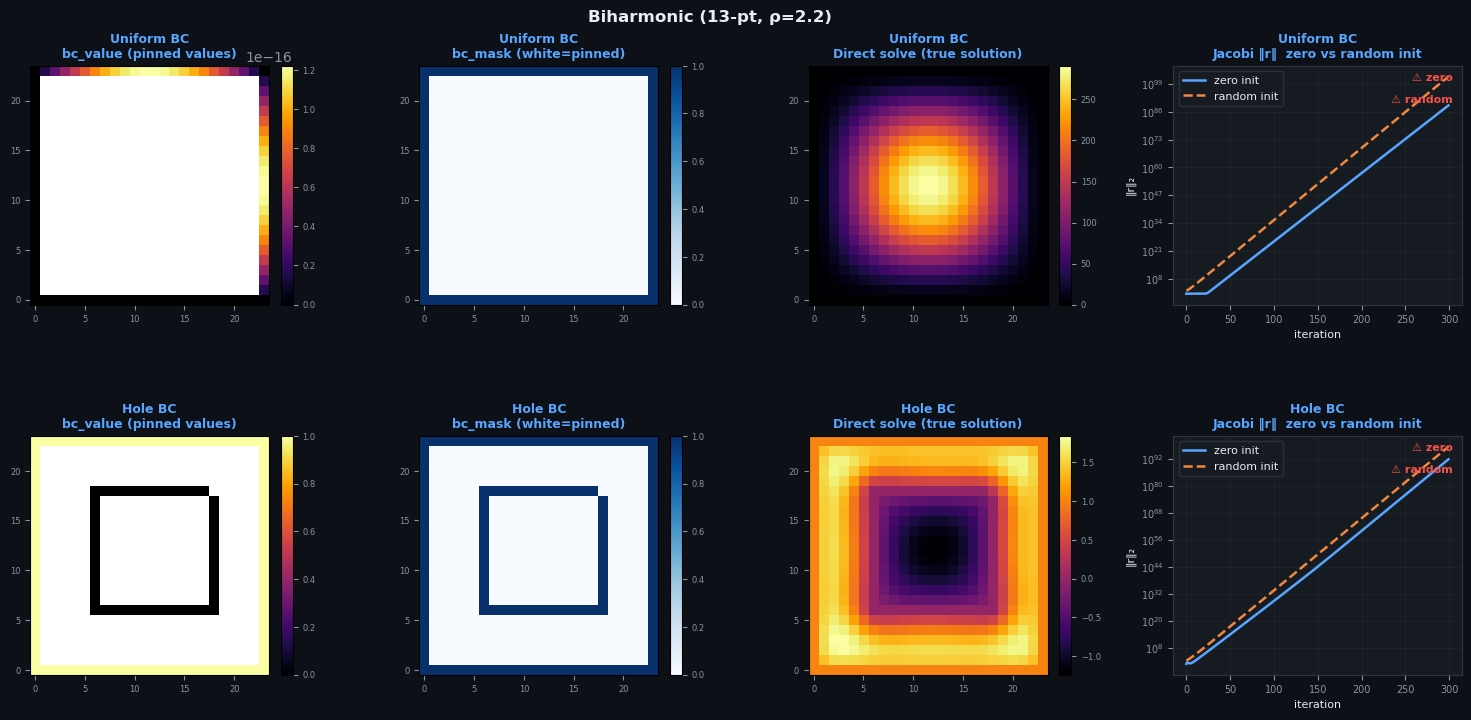

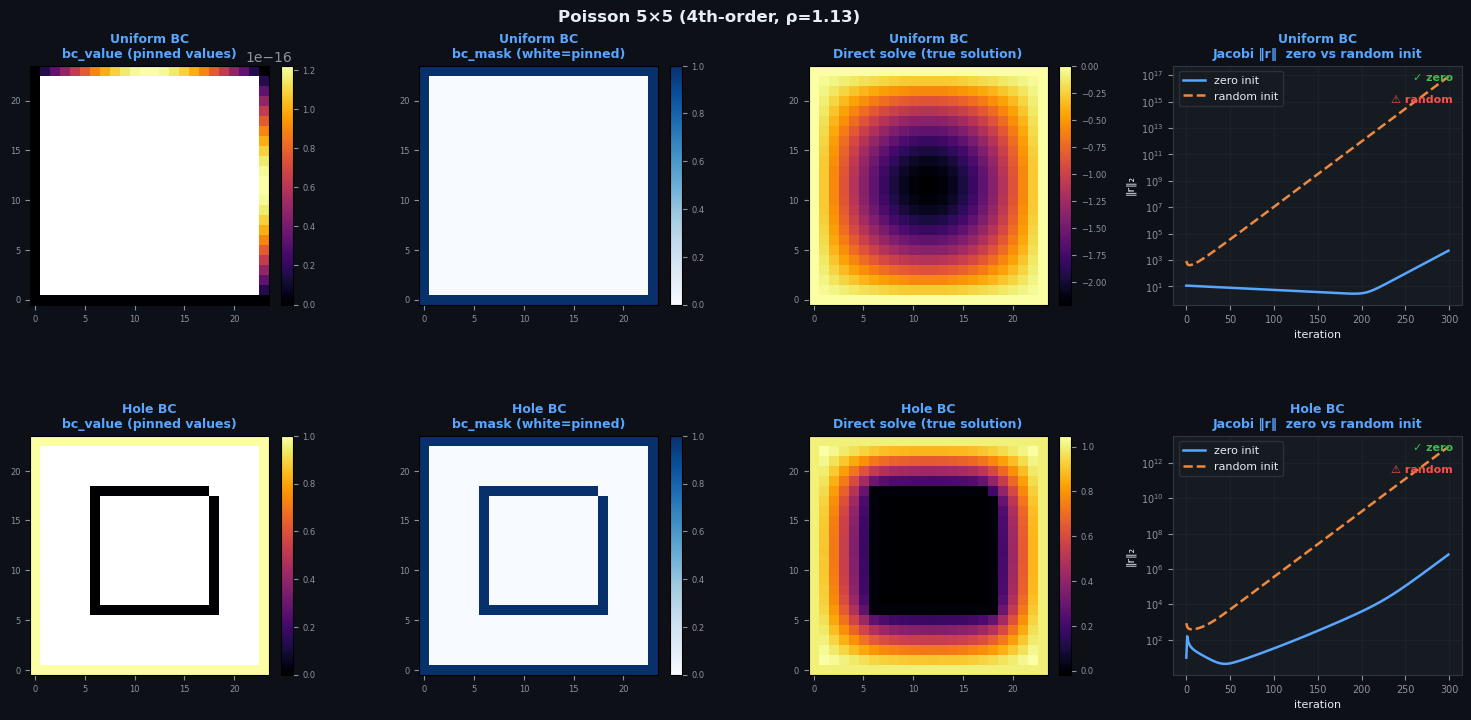

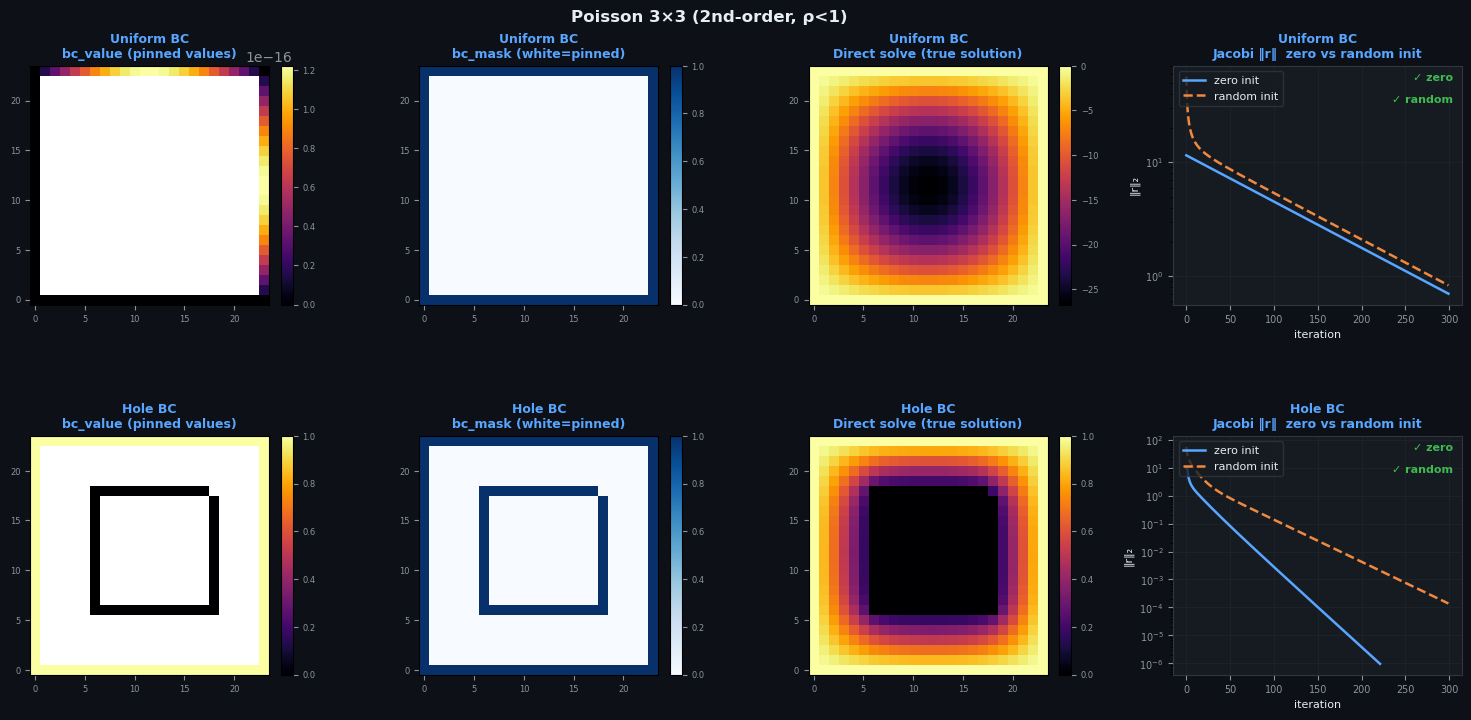

In [8]:
N = 24

# ── Run all three problem types × two BC cases ────────────────────────────
configs = [
    ("biharmonic", "Biharmonic (13-pt, ρ=2.2)"),
    ("poisson5",   "Poisson 5×5 (4th-order, ρ=1.13)"),
    ("poisson3",   "Poisson 3×3 (2nd-order, ρ<1)"),
]
bc_cases = [
    ("uniform", "Uniform BC", make_uniform_bc),
    ("hole",    "Hole BC",    make_hole_bc),
]

# ── Collect results ───────────────────────────────────────────────────────
results = {}
for prob_key, _ in configs:
    for bc_key, _, make_fn in bc_cases:
        bc_v, bc_m, f = make_fn(N)
        key = f"{prob_key}_{bc_key}"

        # route to correct assembler
        if prob_key == "biharmonic":
            A, b = assemble_biharmonic_problem(bc_v, bc_m, f)
        elif prob_key == "poisson5":
            A, b = assemble_poisson5_problem(bc_v, bc_m, f)
        elif prob_key == "poisson3":
            A, b = assemble_poisson_problem(bc_v, bc_m, f)

        print(f"\n[{key}]  shape={A.shape}, nnz={A.nnz}")
        x_ref = direct_solve(A, b)

        # zero init
        print("  Jacobi (zero init)...")
        x_zero, res_zero = jacobi_iteration(A, b, x0=None, max_iter=300)

        # random init (interior only)
        rng = np.random.default_rng(42)
        x0_rand = bc_v.reshape(-1).copy().astype(np.float64)
        interior = (bc_m.reshape(-1) == 0)
        x0_rand[interior] = rng.uniform(-1.0, 1.0, interior.sum())
        print("  Jacobi (random init)...")
        x_rand, res_rand = jacobi_iteration(A, b, x0=x0_rand, max_iter=300)

        results[key] = dict(
            x_ref=x_ref, bc_value=bc_v, bc_mask=bc_m,
            res_zero=res_zero, res_rand=res_rand, N=N,
        )

# ── One figure per problem type, shown inline ────────────────────────────
label_kw = dict(color='#e6edf3', fontsize=8)
title_kw = dict(color='#58a6ff', fontsize=9, fontweight='bold')
cmap_sol  = 'inferno'

def grid2d(x, n): return x.reshape(n, n)

for prob_key, prob_label in configs:
    fig = plt.figure(figsize=(16, 7))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(prob_label, color='#e6edf3', fontsize=12, fontweight='bold', y=1.01)
    gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.35,
                           left=0.06, right=0.97, top=0.93, bottom=0.06)

    for row_idx, (bc_key, bc_label, _) in enumerate(bc_cases):
        key = f"{prob_key}_{bc_key}"
        r   = results[key]
        n   = r['N']
        ref = grid2d(r['x_ref'], n)
        bcv = r['bc_value']
        bcm = r['bc_mask']
        full_label = bc_label

        # col 0 – bc_value: the pinned pixel values across the full grid
        # mask out interior so only pinned pixels are visible
        bcv_display = bcv.copy().astype(np.float64)
        bcv_display[bcm == 0] = np.nan          # interior → blank, not misleading

        ax = fig.add_subplot(gs[row_idx, 0])
        im = ax.imshow(bcv_display, cmap=cmap_sol, origin='lower')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(
            colors='#8b949e', labelsize=6)
        ax.set_title(f'{full_label}\nbc_value (pinned values)', **title_kw)
        ax.tick_params(colors='#8b949e', labelsize=6)

        # col 1 – bc_mask: which pixels are constrained (white) vs free (dark)
        ax = fig.add_subplot(gs[row_idx, 1])
        im = ax.imshow(bcm, cmap='Blues', origin='lower', vmin=0, vmax=1)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(
            colors='#8b949e', labelsize=6)
        ax.set_title(f'{full_label}\nbc_mask (white=pinned)', **title_kw)
        ax.tick_params(colors='#8b949e', labelsize=6)

        # col 2 – direct solve: the true PDE solution given these constraints
        ax = fig.add_subplot(gs[row_idx, 2])
        im = ax.imshow(ref, cmap=cmap_sol, origin='lower')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.tick_params(
            colors='#8b949e', labelsize=6)
        ax.set_title(f'{full_label}\nDirect solve (true solution)', **title_kw)
        ax.tick_params(colors='#8b949e', labelsize=6)

        # col 3 – Jacobi residual: zero init (blue) vs random init (orange dashed)
        ax = fig.add_subplot(gs[row_idx, 3])
        _plot_residuals(ax, r['res_zero'], r['res_rand'],
                        label_kw, title_kw,
                        f'{full_label}\nJacobi ‖r‖  zero vs random init')

    plt.tight_layout()
    plt.show()